In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

PROCESSED_DATA_PATH = "../processed-data"


Đang vẽ biểu đồ Tổng quan Doanh thu...


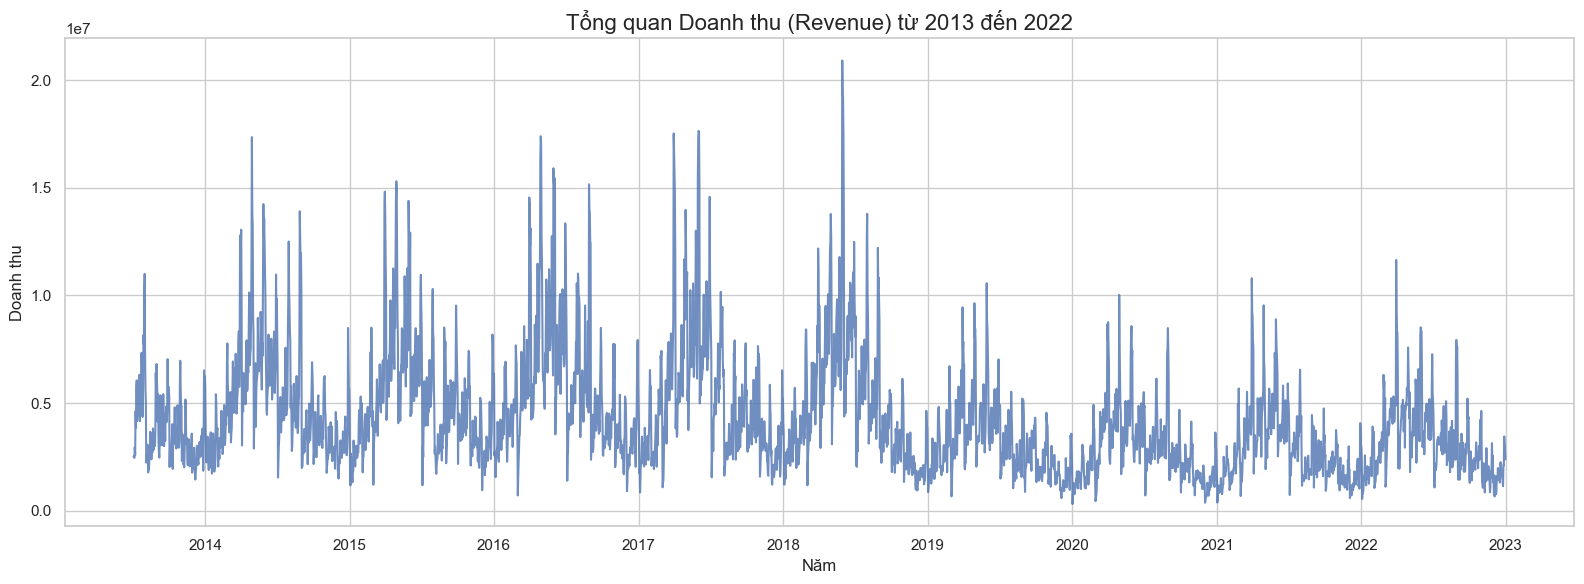


Đang vẽ biểu đồ Chu kỳ mua sắm...


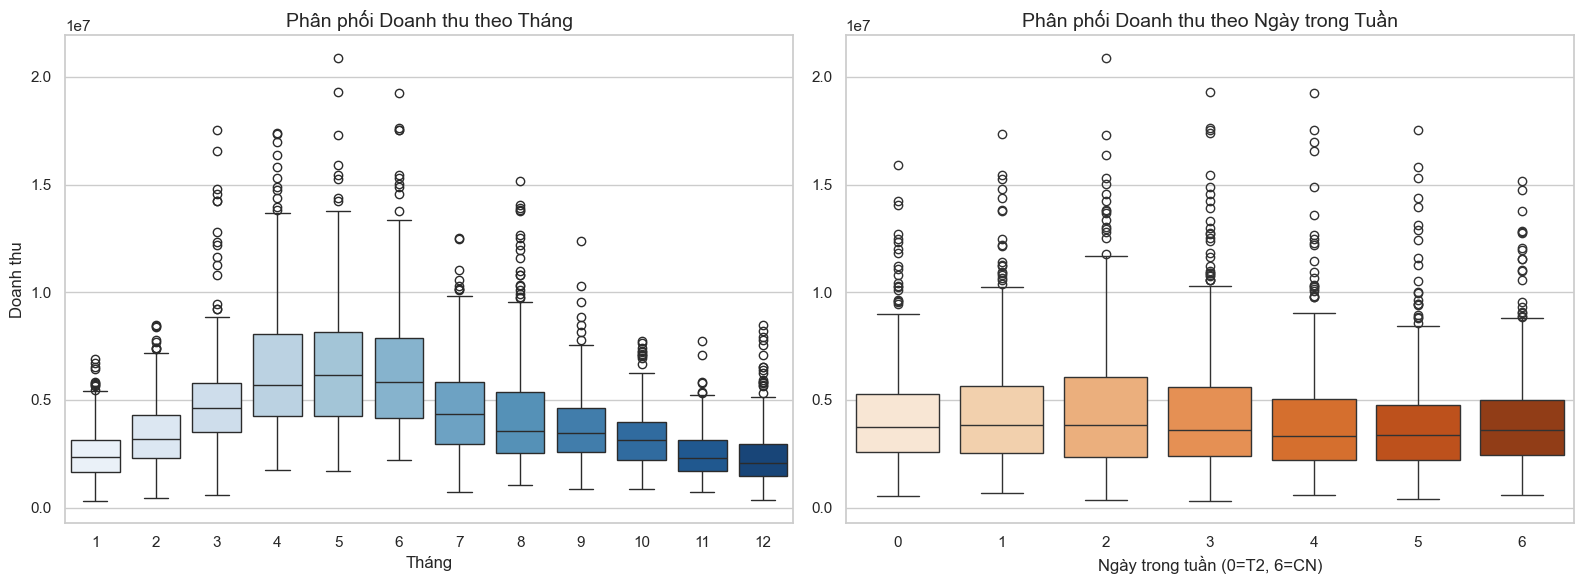


Đang vẽ biểu đồ Hiệu ứng Ngày Lễ / Tết...


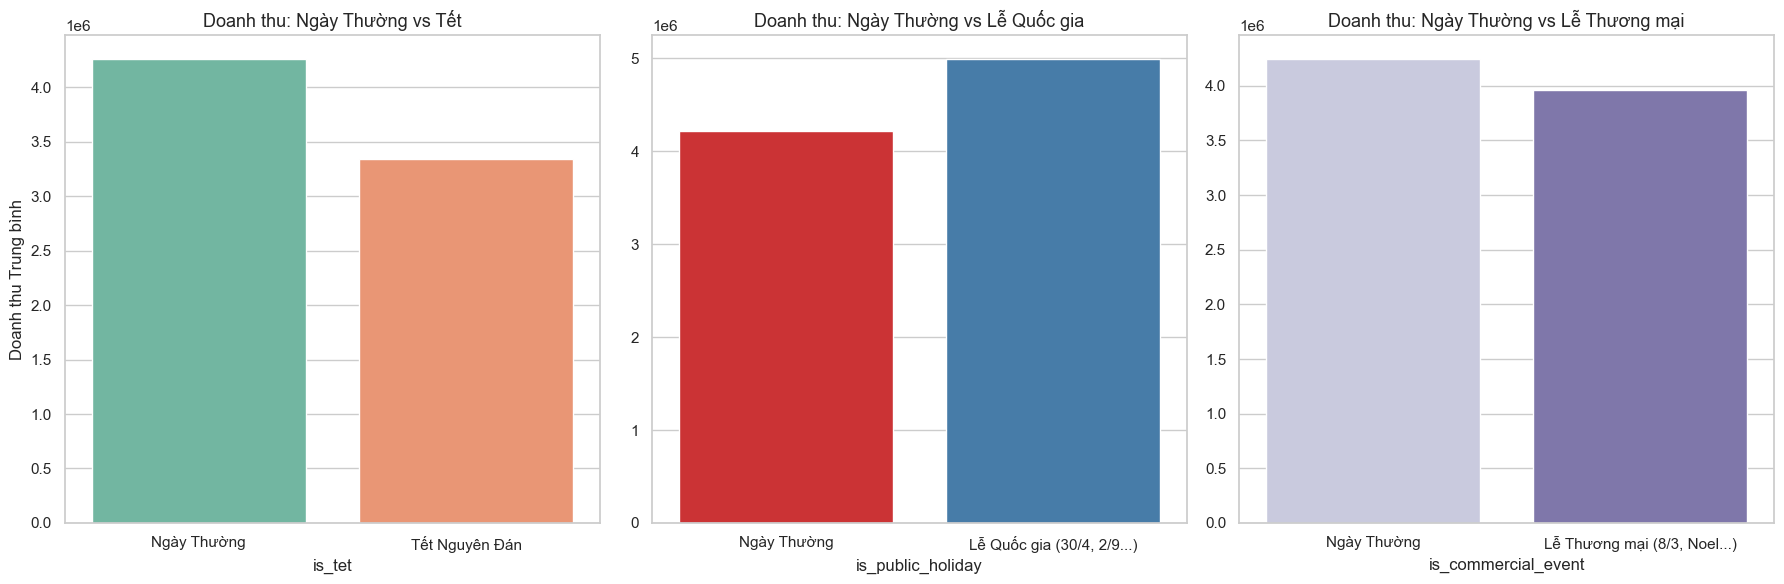

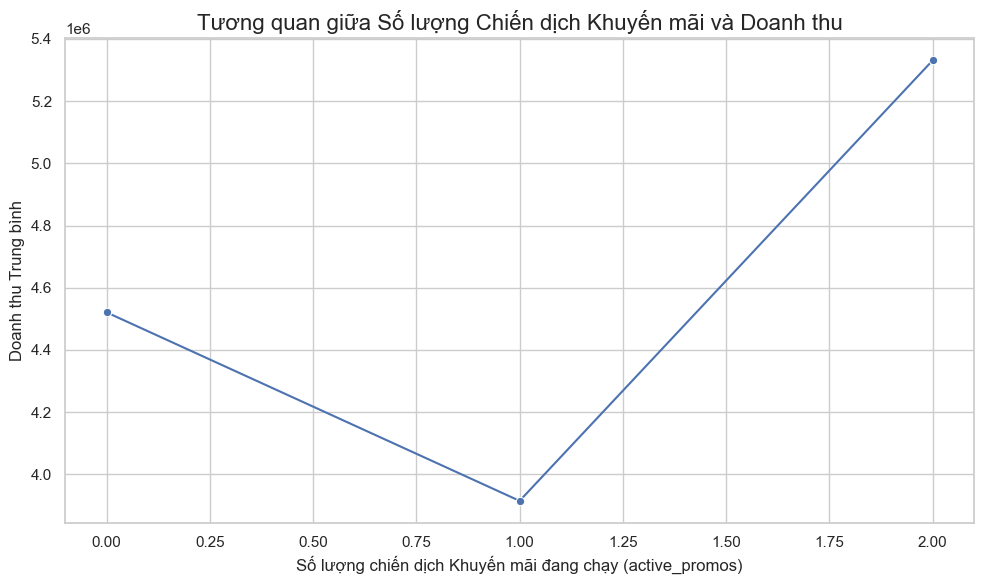

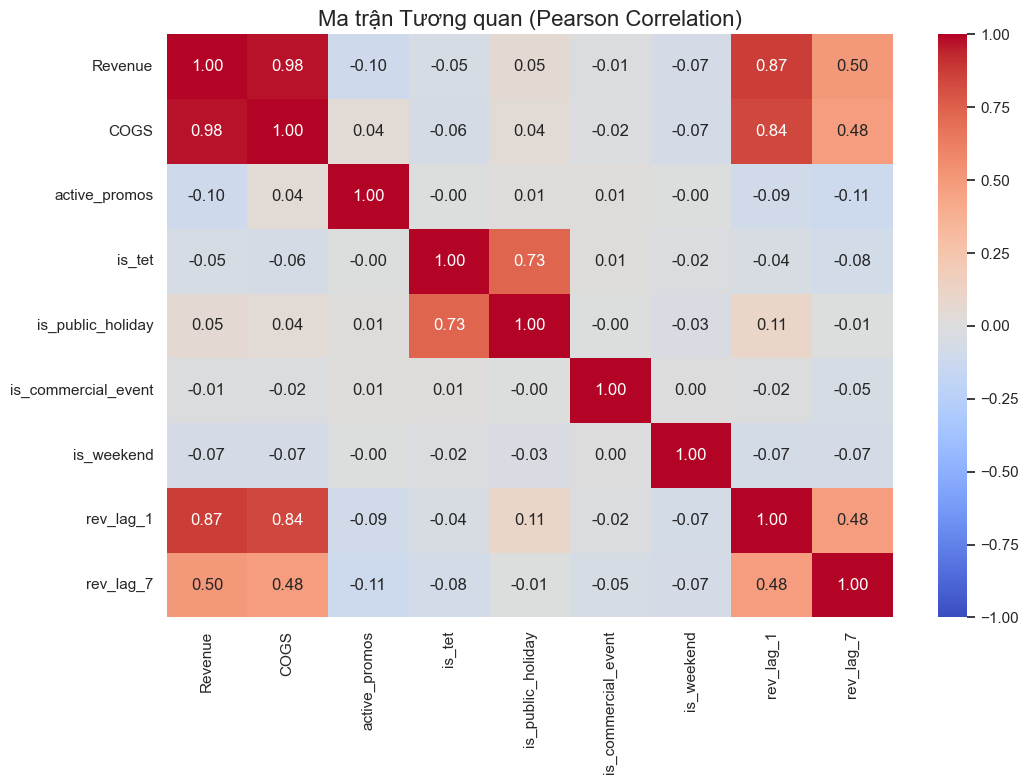

In [4]:
df = pd.read_csv(f'{PROCESSED_DATA_PATH}/final_training_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Chỉ trực quan hóa trên tập Train (vì tập Test chưa có doanh thu thực tế)
train_df = df[df['Split'] == 'Train'].copy()

# ==========================================
# BIỂU ĐỒ 1: TỔNG QUAN DOANH THU THEO THỜI GIAN
# ==========================================
print("\nĐang vẽ biểu đồ Tổng quan Doanh thu...")
plt.figure(figsize=(16, 6))
sns.lineplot(data=train_df, x='Date', y='Revenue', alpha=0.8)
plt.title('Tổng quan Doanh thu (Revenue) từ 2013 đến 2022', fontsize=16)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)
plt.tight_layout()
plt.savefig('eda_1_revenue_trend.png', dpi=300)
plt.show()

# ==========================================
# BIỂU ĐỒ 2: CHU KỲ MUA SẮM (THEO THÁNG & NGÀY TRONG TUẦN)
# ==========================================
print("\nĐang vẽ biểu đồ Chu kỳ mua sắm...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Theo tháng
sns.boxplot(data=train_df, x='month', y='Revenue', ax=axes[0], palette="Blues")
axes[0].set_title('Phân phối Doanh thu theo Tháng', fontsize=14)
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Doanh thu')

# Theo ngày trong tuần (0: Thứ 2, 6: Chủ nhật)
sns.boxplot(data=train_df, x='day_of_week', y='Revenue', ax=axes[1], palette="Oranges")
axes[1].set_title('Phân phối Doanh thu theo Ngày trong Tuần', fontsize=14)
axes[1].set_xlabel('Ngày trong tuần (0=T2, 6=CN)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_2_seasonality.png', dpi=300)
plt.show()

# ==========================================
# BIỂU ĐỒ 3: HIỆU ỨNG TẾT, LỄ QUỐC GIA VÀ LỄ THƯƠNG MẠI
# ==========================================
print("\nĐang vẽ biểu đồ Hiệu ứng Ngày Lễ / Tết...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Tết Nguyên Đán
sns.barplot(data=train_df, x='is_tet', y='Revenue', ax=axes[0], estimator=np.mean, errorbar=None, palette="Set2")
axes[0].set_title('Doanh thu: Ngày Thường vs Tết', fontsize=13)
axes[0].set_xticklabels(['Ngày Thường', 'Tết Nguyên Đán'])
axes[0].set_ylabel('Doanh thu Trung bình')

# 2. Lễ Quốc gia (Public Holidays)
sns.barplot(data=train_df, x='is_public_holiday', y='Revenue', ax=axes[1], estimator=np.mean, errorbar=None, palette="Set1")
axes[1].set_title('Doanh thu: Ngày Thường vs Lễ Quốc gia', fontsize=13)
axes[1].set_xticklabels(['Ngày Thường', 'Lễ Quốc gia (30/4, 2/9...)'])
axes[1].set_ylabel('')

# 3. Lễ Thương mại (Commercial Events)
sns.barplot(data=train_df, x='is_commercial_event', y='Revenue', ax=axes[2], estimator=np.mean, errorbar=None, palette="Purples")
axes[2].set_title('Doanh thu: Ngày Thường vs Lễ Thương mại', fontsize=13)
axes[2].set_xticklabels(['Ngày Thường', 'Lễ Thương mại (8/3, Noel...)'])
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_3_holiday_effects.png', dpi=300)
plt.show()

# ==========================================
# BIỂU ĐỒ 4: TÁC ĐỘNG CỦA KHUYẾN MÃI (PROMOTIONS)
# ==========================================
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='active_promos', y='Revenue', marker="o", errorbar=None)
plt.title('Tương quan giữa Số lượng Chiến dịch Khuyến mãi và Doanh thu', fontsize=16)
plt.xlabel('Số lượng chiến dịch Khuyến mãi đang chạy (active_promos)', fontsize=12)
plt.ylabel('Doanh thu Trung bình', fontsize=12)
plt.tight_layout()
plt.savefig('eda_4_promo_impact.png', dpi=300)
plt.show()

# ==========================================
# BIỂU ĐỒ 5: MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP)
# ==========================================
cols_to_correlate = [
    'Revenue', 'COGS', 'active_promos', 
    'is_tet', 'is_public_holiday', 'is_commercial_event', 'is_weekend',
    'rev_lag_1', 'rev_lag_7'
]

corr_df = train_df[cols_to_correlate].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận Tương quan (Pearson Correlation)', fontsize=16)
plt.tight_layout()
plt.savefig('eda_5_correlation.png', dpi=300)
plt.show()